# 03 — Tabu Search for Seismic Velocity Picking

Tabu Search explores the same neighborhood as Hill Climbing (perturb
one pick at a time), but instead of only accepting improving moves, it
accepts the **best non-tabu neighbor even if it is worse** than the
current solution. A short-term memory (the tabu list) forbids undoing
recent moves for a number of iterations, which is what lets the search
escape local optima **without restarting** from a new random solution.

In this context:
- **Solution**: a set of (time, velocity) pairs along a CDP (same as
  Hill Climbing / Random Search)
- **Move**: perturb one pick's time and/or velocity (same operator as
  Hill Climbing — `BaseOptimizer._generate_neighbor`)
- **Jump move (diversification)**: with probability `p_jump`, one pick
  is re-drawn anywhere inside its own feasible box instead of being
  slightly perturbed
- **Tabu attribute**: `(pick_index, time_sample)` — forbids moving a
  pick's time back to a value it just left, for `tabu_tenure`
  iterations
- **Aspiration**: a tabu move is allowed anyway if it beats the best
  score found so far

**Why the jump move.** The first run on CDP 6800 (plain Tabu Search,
100,000 evaluations) left 4 of the 10 picks stuck at ~1900 m/s on a
flat, near-zero-semblance region of the panel: reaching the semblance
ridge needed several consecutive small moves on the same pick, none of
which improved the score, so they were never chosen. The jump reaches
any position of a pick in a single move.

This notebook is still a **visual check**, not the full statistical
protocol: one detailed run, plus a small paired comparison over 5
seeds (with vs. without the jump move) to tell a systematic effect
from the luck of a single seed.

**Execution order:**
1. Setup
2. Parameters
3. Generate synthetic CDP gather
4. Compute and visualize semblance
5. Run Tabu Search
6. Visualize result
7. Metrics
8. Multi-seed check: with vs. without jump
9. Save results
10. Summary


## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root: {project_root}')


Project root: /home/rafael-garcia/projetos/seismic-velocity-picking


In [2]:
from src.seismic.io        import load_marmousi2_velocity
from src.seismic.synthetic import generate_cdp_gather
from src.seismic.semblance  import compute_semblance
from src.seismic.cases      import water_bottom_time_ms
from src.optimizers.tabu_search import TabuSearch
from src.analysis.metrics import velocity_errors, count_correct_picks

print('All modules imported successfully.')


All modules imported successfully.


## 2. Parameters

In [3]:
# --- Acquisition parameters (same as 01_hill_climbing) ---
CDP_IDX      = 6800          # same column used in the Coursework 1 experiments
N_OFFSETS    = 50            # number of receivers
OFFSET_MIN_M = 100.0         # minimum offset in meters
OFFSET_MAX_M = 3000.0        # maximum offset in meters
DT_MS        = 2.0           # time sampling in ms
T_MAX_MS     = 3000.0        # max record time in ms
F0_HZ        = 30.0          # Ricker wavelet frequency
NOISE_LEVEL  = 0.05          # Gaussian noise amplitude
DATA_SEED    = 42            # seed of the synthetic noise. Kept apart from
                              # the algorithm seed, so changing the algorithm
                              # seed never changes the data being searched.

# --- Semblance parameters ---
VEL_MIN      = 1400.0        # min velocity for semblance scan (m/s)
VEL_MAX      = 3000.0        # max velocity for semblance scan (m/s)
VEL_STEP     = 30.0          # velocity increment (m/s)

# --- Formulation v2 constraints (same as the Coursework 1 report) ---
N_PICKS       = 10            # number of picks to find
MIN_SEP_MS    = 100.0        # minimum time separation between picks
T_MAX_PICK_MS = 2700.0       # excludes the far-offset tail of the record
# t_min_ms is "auto": the water-bottom time of THIS column, computed
# below from its own velocity profile.

# --- Tabu Search parameters ---
MAX_EVALS    = 100000        # evaluation budget (within the 1e5–1e6 range
                              # used in the literature) — the ONLY stopping
                              # criterion in this setup
N_NEIGHBORS  = 30            # neighbors evaluated per iteration
MAX_ITER     = 2 * MAX_EVALS // N_NEIGHBORS
                              # upper bound only: generous enough that the
                              # budget is always reached first, even with
                              # invalid neighbors being skipped
PATIENCE     = MAX_ITER      # effectively disables early stopping, so
                              # every run uses exactly MAX_EVALS evaluations
STEP_TIME    = 5             # max time perturbation (samples)
STEP_VEL     = 50.0          # max velocity perturbation (m/s)
TABU_TENURE  = 15            # iterations a forbidden (pick, time) stays tabu
P_JUMP       = 0.1           # probability that a neighbor is a jump move
SEED         = 42            # algorithm seed for the single detailed run

print('Parameters set.')


Parameters set.


## 3. Generate synthetic CDP gather

In [4]:
MARMOUSI_DIR = os.path.join(project_root, 'data', 'models', 'marmousi2')

vel_model, info = load_marmousi2_velocity(MARMOUSI_DIR, verbose=False)

vel_profile = vel_model[CDP_IDX, :]
offsets_m   = np.linspace(OFFSET_MIN_M, OFFSET_MAX_M,
                          N_OFFSETS, dtype=np.float32)

gather, t_grid, v_rms_true = generate_cdp_gather(
    vel_profile,
    spacing_m   = info['spacing_m'],
    offsets_m   = offsets_m,
    dt_ms       = DT_MS,
    t_max_ms    = T_MAX_MS,
    f0_hz       = F0_HZ,
    noise_level = NOISE_LEVEL,
    seed        = SEED
)
T_MIN_MS = water_bottom_time_ms(vel_profile, info['spacing_m'])

print(f'Gather shape  : {gather.shape}')
print(f'T max         : {t_grid[-1]:.1f} ms')
print(f'Water bottom  : {T_MIN_MS:.1f} ms')
print(f'V RMS range   : {v_rms_true.min():.1f} - {v_rms_true.max():.1f} m/s')


Gather shape  : (50, 1501)
T max         : 3000.0 ms
Water bottom  : 601.7 ms
V RMS range   : 1500.0 - 2510.8 m/s


## 4. Compute semblance

In [5]:
velocities = np.arange(VEL_MIN, VEL_MAX + VEL_STEP,
                       VEL_STEP, dtype=np.float32)

print('Computing semblance...')
semblance = compute_semblance(gather, offsets_m, velocities, dt_ms=DT_MS)
print(f'Semblance shape: {semblance.shape}  (n_vel x n_samples)')
print(f'Max semblance  : {semblance.max():.4f}')


Computing semblance...
Semblance shape: (55, 1501)  (n_vel x n_samples)
Max semblance  : 0.9855


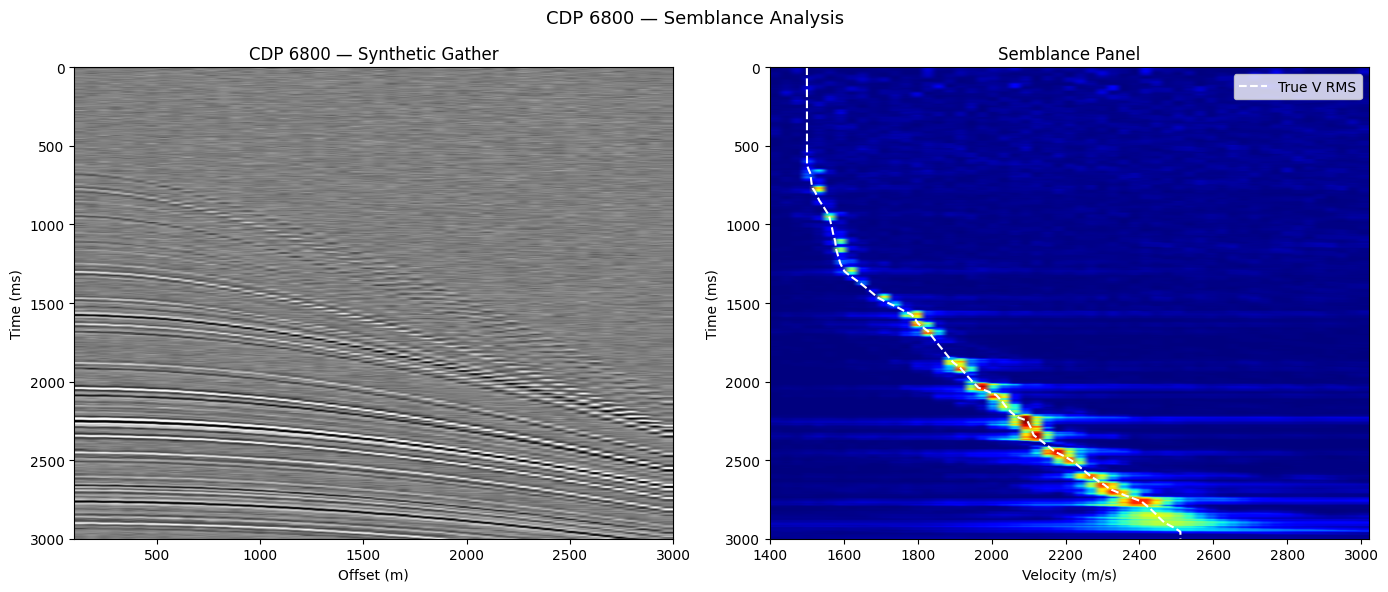

Figure saved.


In [6]:
os.makedirs(os.path.join(project_root, 'results', 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vmax = np.percentile(np.abs(gather), 98)
axes[0].imshow(
    gather.T, aspect='auto', cmap='gray',
    vmin=-vmax, vmax=vmax,
    extent=[offsets_m[0], offsets_m[-1], t_grid[-1], t_grid[0]]
)
axes[0].set_xlabel('Offset (m)')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title(f'CDP {CDP_IDX} — Synthetic Gather')

axes[1].imshow(
    semblance.T, aspect='auto', cmap='jet',
    vmin=0, vmax=1,
    extent=[velocities[0], velocities[-1], t_grid[-1], t_grid[0]]
)
axes[1].plot(v_rms_true, t_grid, 'w--', linewidth=1.5, label='True V RMS')
axes[1].set_xlabel('Velocity (m/s)')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Semblance Panel')
axes[1].legend()

plt.suptitle(f'CDP {CDP_IDX} — Semblance Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '03_semblance_before_picking.png'), dpi=150
)
plt.show()
print('Figure saved.')

## 5. Run Tabu Search

In [7]:
ts = TabuSearch(
    traces      = gather,
    offsets     = offsets_m,
    dt_ms       = DT_MS,
    vel_min     = VEL_MIN,
    vel_max     = VEL_MAX,
    n_picks     = N_PICKS,
    max_iter    = MAX_ITER,
    seed        = SEED,
    step_time   = STEP_TIME,
    step_vel    = STEP_VEL,
    n_neighbors = N_NEIGHBORS,
    tabu_tenure = TABU_TENURE,
    patience    = PATIENCE,
    p_jump      = P_JUMP,
    max_evals   = MAX_EVALS,
    min_sep_ms  = MIN_SEP_MS,
    t_min_ms    = T_MIN_MS,
    t_max_ms    = T_MAX_PICK_MS,
)

print('Running Tabu Search...')
ts.run()

times_pick, vels_pick = ts.get_result()

print(f'Execution time : {ts.exec_time_s:.2f} s')
print(f'Evaluations    : {ts.n_evals}')
print(f'Iterations run : {len(ts.history)} / {MAX_ITER}')
print(f'Best score     : {ts.best_score:.4f}')
print()
print('Picks found (time_ms, velocity_m/s):')
for t, v in zip(times_pick * DT_MS, vels_pick):
    print(f'  t={t:7.1f} ms   v={v:.1f} m/s')


Running Tabu Search...
Execution time : 86.26 s
Evaluations    : 100000
Iterations run : 4414 / 6666
Best score     : 0.8352

Picks found (time_ms, velocity_m/s):
  t=  672.0 ms   v=1508.5 m/s
  t=  772.0 ms   v=1517.2 m/s
  t=  938.0 ms   v=1560.2 m/s
  t= 1170.0 ms   v=1576.9 m/s
  t= 1292.0 ms   v=1601.5 m/s
  t= 1588.0 ms   v=1774.8 m/s
  t= 1876.0 ms   v=1894.8 m/s
  t= 2034.0 ms   v=1965.3 m/s
  t= 2246.0 ms   v=2088.8 m/s
  t= 2346.0 ms   v=2110.9 m/s


In [8]:
print(f'Stopped by              : {ts.stop_reason}')
print(f'Evaluations / iteration : {ts.n_evals / len(ts.history):.1f} '
      f'(of {N_NEIGHBORS} neighbors generated)')
print(f'Active tabu attributes  : {ts.active_tabu_size} (at most {TABU_TENURE})')
print(f'Distinct attributes ever made tabu: {ts.n_tabu_attributes} '
      f'over {len(ts.history)} iterations')
print(f'Jump moves              : {ts.jump_stats["proposed"]} proposed, '
      f'{ts.jump_stats["accepted"]} accepted')

Stopped by              : budget
Evaluations / iteration : 22.7 (of 30 neighbors generated)
Active tabu attributes  : 15 (at most 15)
Distinct attributes ever made tabu: 342 over 4414 iterations
Jump moves              : 13167 proposed, 140 accepted


## 6. Visualize result

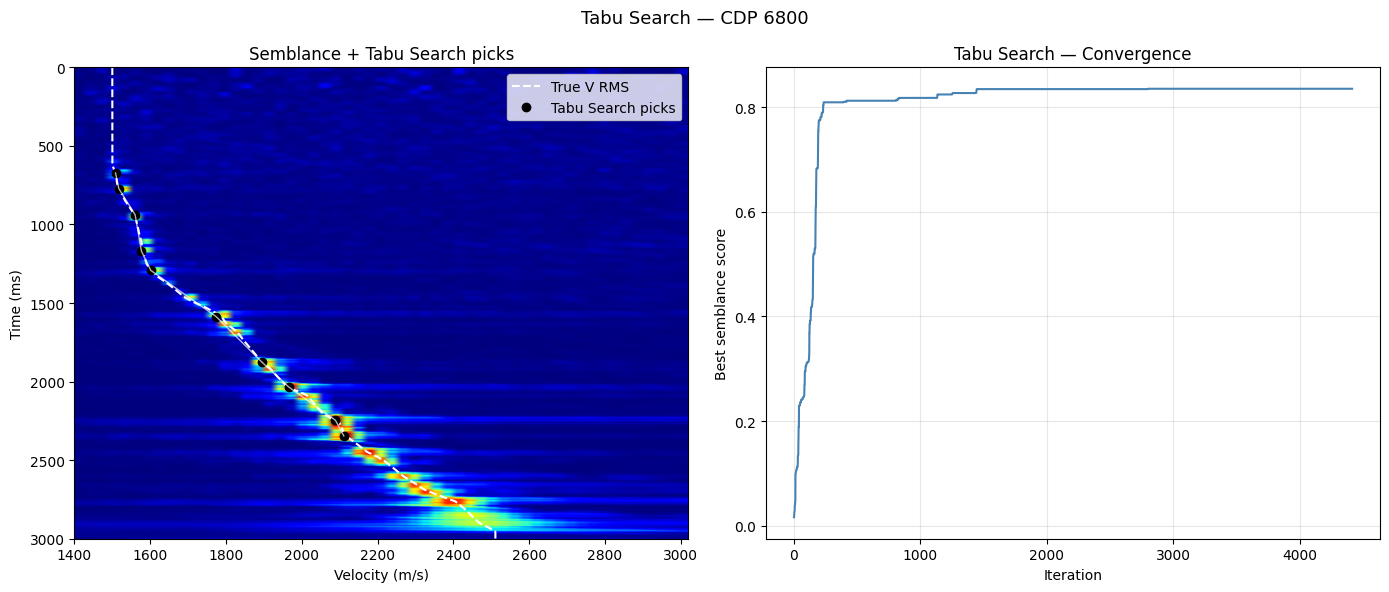

Figure saved.


In [9]:
times_ms = times_pick * DT_MS

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(
    semblance.T, aspect='auto', cmap='jet',
    vmin=0, vmax=1,
    extent=[velocities[0], velocities[-1], t_grid[-1], t_grid[0]]
)
axes[0].plot(v_rms_true, t_grid,
             'w--', linewidth=1.5, label='True V RMS')
axes[0].plot(vels_pick, times_ms,
             'ko', markersize=6, label='Tabu Search picks')
axes[0].plot(vels_pick, times_ms,
             'w-', linewidth=1.0, alpha=0.7)
axes[0].set_xlabel('Velocity (m/s)')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Semblance + Tabu Search picks')
axes[0].legend()

axes[1].plot(ts.history, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Best semblance score')
axes[1].set_title('Tabu Search — Convergence')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Tabu Search — CDP {CDP_IDX}', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '03_tabu_search_result.png'), dpi=150
)
plt.show()
print('Figure saved.')

## 7. Metrics

In [10]:
v_true_at_picks = np.interp(times_ms, t_grid, v_rms_true)

rmse = np.sqrt(np.mean((vels_pick - v_true_at_picks) ** 2))
mae  = np.mean(np.abs(vels_pick - v_true_at_picks))
mape = np.mean(np.abs((vels_pick - v_true_at_picks) / v_true_at_picks)) * 100

print('=== Metrics ===')
print(f'RMSE : {rmse:.2f} m/s')
print(f'MAE  : {mae:.2f} m/s')
print(f'MAPE : {mape:.2f} %')
print(f'Time : {ts.exec_time_s:.2f} s')
print(f'Score: {ts.best_score:.4f}')

print()
print(f'{"Time (ms)":>12} {"Picked (m/s)":>14} {"True (m/s)":>12} {"Error (m/s)":>12}')
print('-' * 54)
for t, vp, vt in zip(times_ms, vels_pick, v_true_at_picks):
    err = vp - vt
    print(f'{t:12.1f} {vp:14.1f} {vt:12.1f} {err:+12.1f}')


=== Metrics ===
RMSE : 5.25 m/s
MAE  : 3.58 m/s
MAPE : 0.20 %
Time : 86.26 s
Score: 0.8352

   Time (ms)   Picked (m/s)   True (m/s)  Error (m/s)
------------------------------------------------------
       672.0         1508.5       1508.8         -0.3
       772.0         1517.2       1516.3         +1.0
       938.0         1560.2       1558.6         +1.6
      1170.0         1576.9       1580.7         -3.8
      1292.0         1601.5       1600.1         +1.5
      1588.0         1774.8       1788.6        -13.8
      1876.0         1894.8       1895.0         -0.2
      2034.0         1965.3       1962.0         +3.3
      2246.0         2088.8       2093.4         -4.6
      2346.0         2110.9       2116.5         -5.6


## 8. Multi-seed check: with vs. without jump

A single run cannot tell whether stuck picks are systematic or bad
luck. Here the same 5 algorithm seeds are run twice — plain Tabu
Search (`p_jump = 0`) and with the jump move (`p_jump = P_JUMP`) — on
the **same gather**, so each seed gives a paired comparison.

This is still a small check, not the statistical protocol of the
report (no Wilcoxon test with 5 pairs). Expected run time: about
10 runs × ~80 s ≈ 13–14 min.

Pick classification (relative error against the true V_rms):
**correct** ≤ 2%, **small** 2–5%, **large** > 5%.


In [11]:
SEEDS    = [42, 43, 44, 45, 46]
VARIANTS = {'plain': 0.0, 'jump': P_JUMP}

multi_runs = []
for seed in SEEDS:
    for variant, p_jump in VARIANTS.items():
        run = TabuSearch(
            traces=gather, offsets=offsets_m, dt_ms=DT_MS,
            vel_min=VEL_MIN, vel_max=VEL_MAX, n_picks=N_PICKS,
            max_iter=MAX_ITER, seed=seed,
            step_time=STEP_TIME, step_vel=STEP_VEL,
            n_neighbors=N_NEIGHBORS, tabu_tenure=TABU_TENURE,
            patience=PATIENCE, p_jump=p_jump, max_evals=MAX_EVALS,
            min_sep_ms=MIN_SEP_MS, t_min_ms=T_MIN_MS,
            t_max_ms=T_MAX_PICK_MS,
        ).run()

        t_s, v_s = run.get_result()
        t_ms     = t_s * DT_MS
        err      = velocity_errors(t_ms, v_s, t_grid, v_rms_true)
        rel      = np.abs(np.array(err['errors'])) / np.array(err['v_true'])
        n_ok     = count_correct_picks(t_ms, v_s, t_grid, v_rms_true)['n_correct']

        multi_runs.append({
            'seed': seed, 'variant': variant, 'p_jump': p_jump,
            'best_score': float(run.best_score),
            'n_correct': n_ok,
            'n_small':   int(np.sum((rel > 0.02) & (rel <= 0.05))),
            'n_large':   int(np.sum(rel > 0.05)),
            'rmse': err['rmse'], 'mae': err['mae'],
            'exec_time_s': float(run.exec_time_s),
            'n_evals': run.n_evals, 'stop_reason': run.stop_reason,
            'jumps_accepted': run.jump_stats['accepted'],
            'times_ms': t_ms.tolist(), 'vels': v_s.tolist(),
            'history': list(run.history),
        })
        print(f'seed {seed}  {variant:5s}  score={run.best_score:.4f}  '
              f'correct={n_ok:2d}/{N_PICKS}  rmse={err["rmse"]:7.1f}  '
              f'time={run.exec_time_s:5.1f}s  stop={run.stop_reason}')


seed 42  plain  score=0.5487  correct= 6/10  rmse=  163.6  time= 83.2s  stop=budget
seed 42  jump   score=0.8352  correct=10/10  rmse=    5.2  time= 88.0s  stop=budget
seed 43  plain  score=0.1082  correct= 1/10  rmse=  571.0  time= 84.0s  stop=budget
seed 43  jump   score=0.8466  correct=10/10  rmse=    7.2  time= 82.2s  stop=budget
seed 44  plain  score=0.1060  correct= 1/10  rmse=  634.4  time= 83.4s  stop=budget
seed 44  jump   score=0.8612  correct=10/10  rmse=    6.9  time= 80.5s  stop=budget
seed 45  plain  score=0.1087  correct= 1/10  rmse=  601.5  time= 81.4s  stop=budget
seed 45  jump   score=0.8910  correct=10/10  rmse=    7.1  time= 78.1s  stop=budget
seed 46  plain  score=0.1864  correct= 3/10  rmse=  435.4  time= 77.1s  stop=budget
seed 46  jump   score=0.8758  correct=10/10  rmse=    5.8  time= 76.7s  stop=budget


In [12]:
print(f'{"Seed":>6} {"Variant":>8} {"Score":>8} {"Correct":>8} {"Small":>6} '
      f'{"Large":>6} {"RMSE":>8} {"MAE":>8} {"Jumps acc.":>11}')
print('-' * 80)
for r in multi_runs:
    print(f'{r["seed"]:>6} {r["variant"]:>8} {r["best_score"]:>8.4f} '
          f'{r["n_correct"]:>8} {r["n_small"]:>6} {r["n_large"]:>6} '
          f'{r["rmse"]:>8.1f} {r["mae"]:>8.1f} {r["jumps_accepted"]:>11}')

# Paired summary (same seed, plain vs. jump)
by = {(r['seed'], r['variant']): r for r in multi_runs}
print()
print(f'{"Metric":>12} {"plain (mean)":>14} {"jump (mean)":>13} '
      f'{"jump better":>12} {"ties":>6}')
print('-' * 62)
for key, higher_is_better in [('best_score', True), ('n_correct', True),
                              ('n_large', False), ('rmse', False)]:
    a = np.array([by[(s, 'plain')][key] for s in SEEDS], dtype=float)
    b = np.array([by[(s, 'jump')][key]  for s in SEEDS], dtype=float)
    better = np.sum(b > a) if higher_is_better else np.sum(b < a)
    ties   = np.sum(np.isclose(a, b))
    print(f'{key:>12} {a.mean():>14.4f} {b.mean():>13.4f} '
          f'{int(better):>9}/{len(SEEDS)} {int(ties):>6}')


  Seed  Variant    Score  Correct  Small  Large     RMSE      MAE  Jumps acc.
--------------------------------------------------------------------------------
    42    plain   0.5487        6      0      4    163.6    101.2           0
    42     jump   0.8352       10      0      0      5.2      3.6         140
    43    plain   0.1082        1      0      9    571.0    478.6           0
    43     jump   0.8466       10      0      0      7.2      6.1         113
    44    plain   0.1060        1      0      9    634.4    578.3           0
    44     jump   0.8612       10      0      0      6.9      5.3         151
    45    plain   0.1087        1      0      9    601.5    560.8           0
    45     jump   0.8910       10      0      0      7.1      5.9         147
    46    plain   0.1864        3      0      7    435.4    353.0           0
    46     jump   0.8758       10      0      0      5.8      4.2         171

      Metric   plain (mean)   jump (mean)  jump better   tie

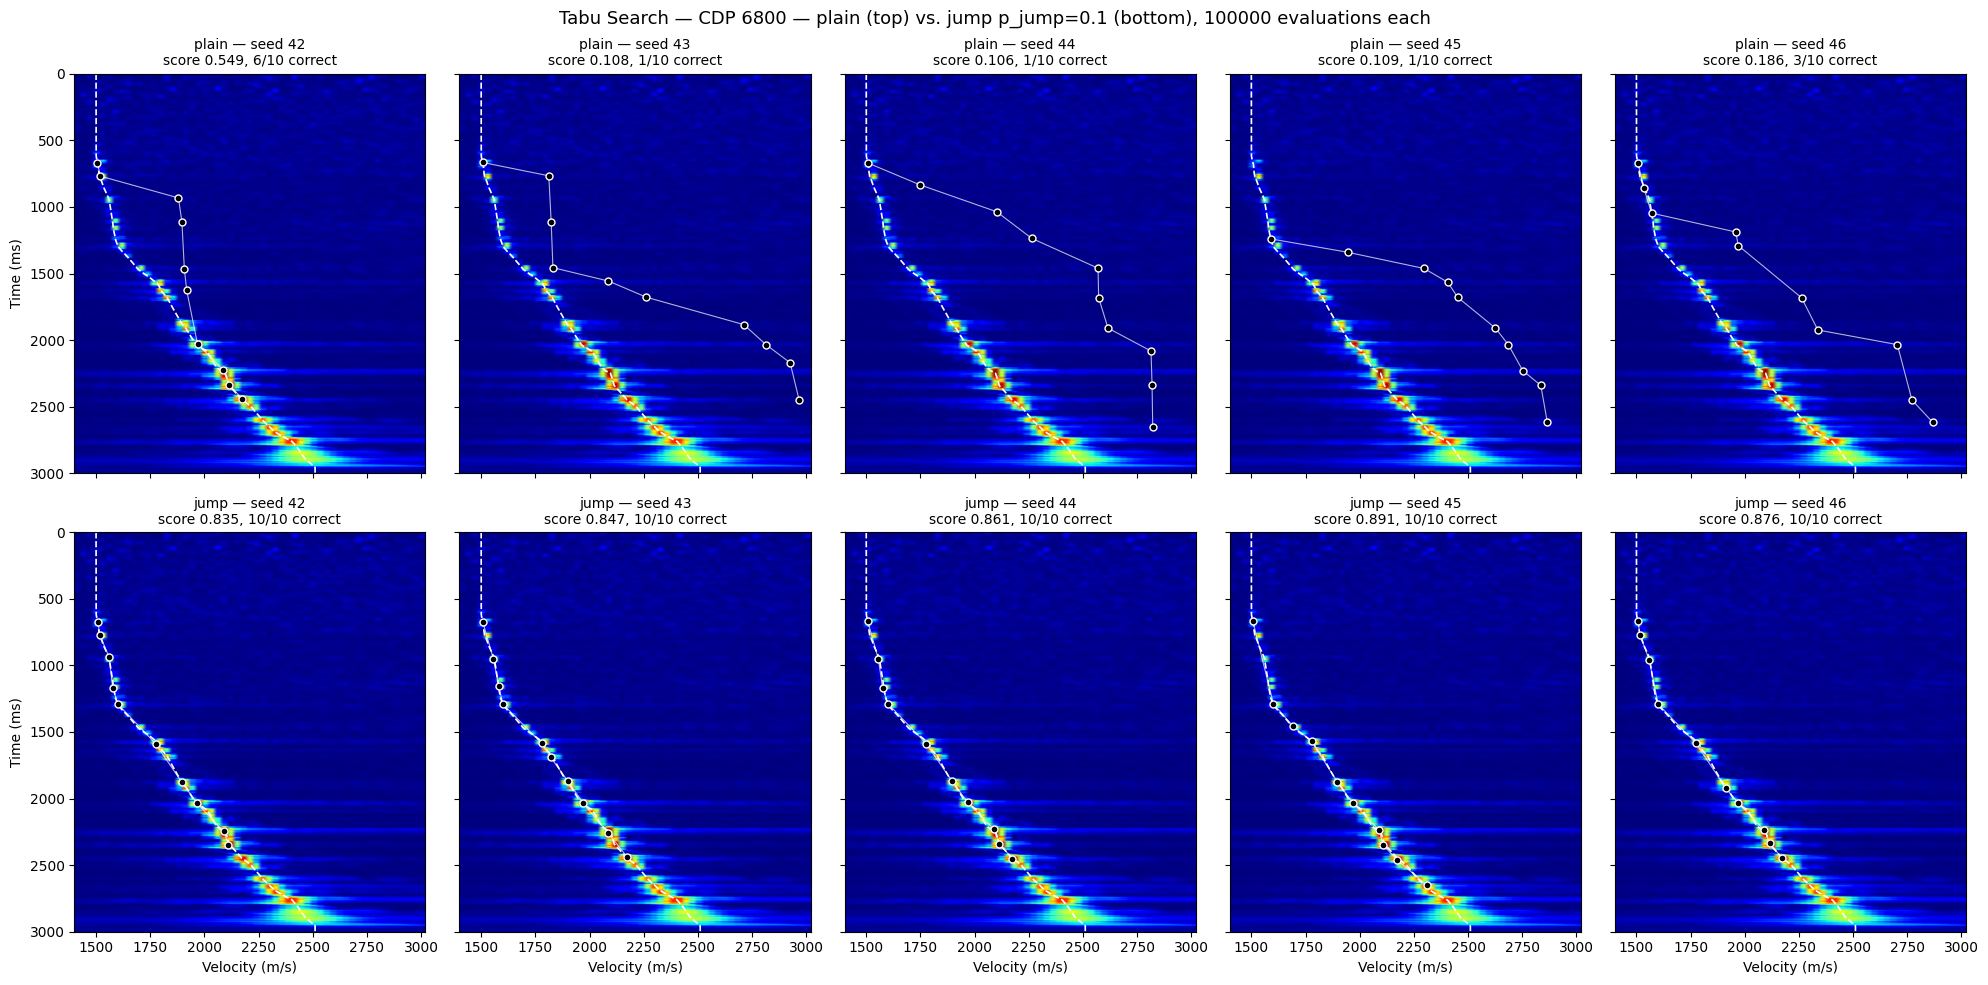

Figure saved.


In [13]:
fig, axes = plt.subplots(2, len(SEEDS), figsize=(4.0 * len(SEEDS), 10),
                         sharex=True, sharey=True)

for row, variant in enumerate(VARIANTS):
    for col, seed in enumerate(SEEDS):
        r  = by[(seed, variant)]
        ax = axes[row, col]
        ax.imshow(
            semblance.T, aspect='auto', cmap='jet', vmin=0, vmax=1,
            extent=[velocities[0], velocities[-1], t_grid[-1], t_grid[0]]
        )
        ax.plot(v_rms_true, t_grid, 'w--', linewidth=1.2)
        ax.plot(r['vels'], r['times_ms'], 'w-', linewidth=0.8, alpha=0.7)
        ax.plot(r['vels'], r['times_ms'], 'ko', markersize=5,
                markeredgecolor='white')
        ax.set_title(f'{variant} — seed {seed}\n'
                     f'score {r["best_score"]:.3f}, '
                     f'{r["n_correct"]}/{N_PICKS} correct', fontsize=10)
        if col == 0:
            ax.set_ylabel('Time (ms)')
        if row == 1:
            ax.set_xlabel('Velocity (m/s)')

plt.suptitle(f'Tabu Search — CDP {CDP_IDX} — plain (top) vs. jump '
             f'p_jump={P_JUMP} (bottom), {MAX_EVALS} evaluations each',
             fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '03_tabu_search_multiseed_picks.png'), dpi=150
)
plt.show()
print('Figure saved.')


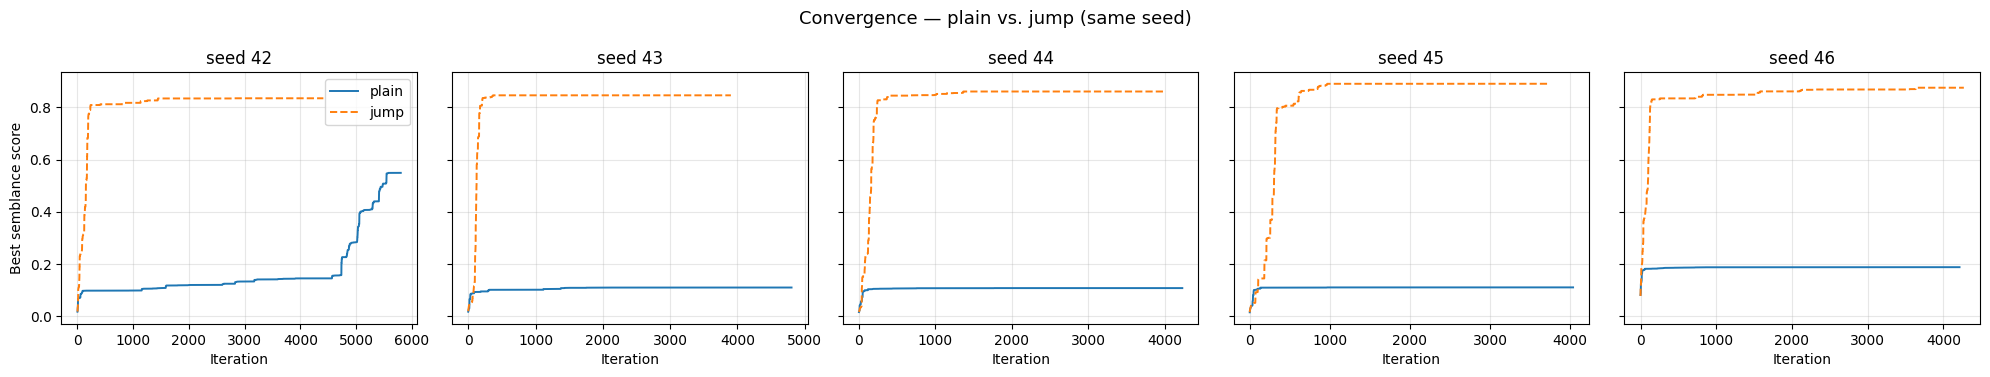

Figure saved.


In [ ]:
fig, axes = plt.subplots(1, len(SEEDS), figsize=(4.0 * len(SEEDS), 3.8),
                         sharey=True)

for ax, seed in zip(axes, SEEDS):
    for variant, style in [('plain', '-'), ('jump', '--')]:
        r = by[(seed, variant)]
        ax.plot(r['history'], style, linewidth=1.4, label=variant)
    ax.set_title(f'seed {seed}')
    ax.set_xlabel('Iteration')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Best semblance score')
axes[0].legend()
plt.suptitle('Convergence — plain vs. jump (same seed)', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '03_tabu_search_multiseed_convergence.png'), dpi=150
)
plt.show()
print('Figure saved.')


## 9. Save results

In [15]:
os.makedirs(os.path.join(project_root, 'results', 'metrics'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'results', 'picks'),   exist_ok=True)

metrics = {
    'algorithm':    'TabuSearch',
    'cdp':          CDP_IDX,
    'rmse':         float(rmse),
    'mae':          float(mae),
    'mape':         float(mape),
    'best_score':   float(ts.best_score),
    'exec_time_s':  float(ts.exec_time_s),
    'n_evals':      ts.n_evals,
    'n_picks':      N_PICKS,
    'max_iter':     MAX_ITER,
    'iters_run':    len(ts.history),
    'tabu_tenure':  TABU_TENURE,
    'p_jump':       P_JUMP,
    'max_evals':    MAX_EVALS,
    'stop_reason':  ts.stop_reason,
    'jumps_accepted': ts.jump_stats['accepted'],
    'patience':     PATIENCE,
    'seed':         SEED,
    'data_seed':    DATA_SEED,
}

metrics_path = os.path.join(project_root, 'results', 'metrics',
                            'tabu_search.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

picks_path = os.path.join(project_root, 'results', 'picks',
                          'tabu_search.npy')
np.save(picks_path, {
    'times_ms':  times_ms,
    'vels_pick': vels_pick,
    'v_true':    v_true_at_picks,
})

history_path = os.path.join(project_root, 'results', 'metrics',
                            'tabu_search_history.npy')
np.save(history_path, np.array(ts.history))

multiseed_path = os.path.join(project_root, 'results', 'metrics',
                              'tabu_search_multiseed.json')
with open(multiseed_path, 'w') as f:
    json.dump({'seeds': SEEDS, 'variants': VARIANTS,
               'max_evals': MAX_EVALS, 'runs': multi_runs}, f, indent=2)

print('Results saved:')
print(f'  Metrics : {metrics_path}')
print(f'  Picks   : {picks_path}')
print(f'  History : {history_path}')
print(f'  Multi-seed : {multiseed_path}')
print()
print(json.dumps(metrics, indent=2))


Results saved:
  Metrics : /home/rafael-garcia/projetos/seismic-velocity-picking/results/metrics/tabu_search.json
  Picks   : /home/rafael-garcia/projetos/seismic-velocity-picking/results/picks/tabu_search.npy
  History : /home/rafael-garcia/projetos/seismic-velocity-picking/results/metrics/tabu_search_history.npy
  Multi-seed : /home/rafael-garcia/projetos/seismic-velocity-picking/results/metrics/tabu_search_multiseed.json

{
  "algorithm": "TabuSearch",
  "cdp": 6800,
  "rmse": 5.248797322824542,
  "mae": 3.578471669401938,
  "mape": 0.19614103507051348,
  "best_score": 0.835172027349472,
  "exec_time_s": 86.25560066300022,
  "n_evals": 100000,
  "n_picks": 10,
  "max_iter": 6666,
  "iters_run": 4414,
  "tabu_tenure": 15,
  "p_jump": 0.1,
  "max_evals": 100000,
  "stop_reason": "budget",
  "jumps_accepted": 140,
  "patience": 6666,
  "seed": 42,
  "data_seed": 42
}


## 10. Summary

This notebook is a **visual check** of Tabu Search on the main case
(CDP 6800) with a budget of 100,000 evaluations per run: one detailed
run, plus a small paired comparison over 5 seeds of the plain search
against the search with the jump move.

**What this notebook does NOT do yet:**
- No comparison against Hill Climbing or Random Search — Coursework 2
  is focused on Tabu Search (and, later, a Tabu Search + Simulated
  Annealing hybrid), not on repeating the Coursework 1 comparisons.
- No statistical protocol (30 paired seeds, Wilcoxon test) — 5 seeds
  are only enough to see whether an effect looks systematic.
- No tuning of `p_jump` or `tabu_tenure`: one change at a time, so any
  difference can be attributed to the jump move alone.

**Next steps:**
- If the jump move helps consistently, run the full statistical
  protocol (more seeds, all test cases) through the experiment scripts.
- If picks still get stuck, consider guiding which pick is moved by
  its own semblance (the objective is a mean of per-pick semblances,
  so weak picks can be identified at no extra cost).
- A future `TabuSearchSA` — a Tabu Search + Simulated Annealing hybrid
  — discussed conceptually but not implemented yet.
